In [2]:
!pip install -q -U keras-tuner


In [3]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
import tensorflow as tf
from sklearn.model_selection import KFold
from matplotlib import pyplot as plt
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, roc_auc_score, roc_curve
import numpy as np
import keras_tuner as kt  # Keras Tuner

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Set global seeds for reproducibility
seed = 123
tf.random.set_seed(seed)
np.random.seed(seed)

In [5]:
data_dir = '/content/drive/My Drive/breakhis'  # Replace with your actual path to the dataset


In [6]:
from keras.saving import register_keras_serializable

@register_keras_serializable()
class PAM(tf.keras.layers.Layer):
    """Position Attention Module"""
    def __init__(self):
        super(PAM, self).__init__()

    def build(self, input_shape):
        self.query_conv = tf.keras.layers.Conv2D(input_shape[-1] // 8, kernel_size=1)
        self.key_conv = tf.keras.layers.Conv2D(input_shape[-1] // 8, kernel_size=1)
        self.value_conv = tf.keras.layers.Conv2D(input_shape[-1], kernel_size=1)
        self.gamma = self.add_weight(name="gamma", shape=(), initializer="zeros", trainable=True)

    def call(self, inputs):
        query = self.query_conv(inputs)  # [batch, h, w, c//8]
        key = self.key_conv(inputs)  # [batch, h, w, c//8]
        value = self.value_conv(inputs)  # [batch, h, w, c]

        # Compute attention
        query = tf.reshape(query, [tf.shape(query)[0], -1, tf.shape(query)[-1]])  # [batch, hw, c//8]
        key = tf.transpose(tf.reshape(key, [tf.shape(key)[0], -1, tf.shape(key)[-1]]), perm=[0, 2, 1])  # [batch, c//8, hw]
        energy = tf.matmul(query, key)  # [batch, hw, hw]
        attention = tf.nn.softmax(energy, axis=-1)  # Spatial attention

        value = tf.reshape(value, [tf.shape(value)[0], -1, tf.shape(value)[-1]])  # [batch, hw, c]
        out = tf.matmul(attention, value)  # [batch, hw, c]
        out = tf.reshape(out, tf.shape(inputs))  # Restore shape
        return self.gamma * out + inputs


@register_keras_serializable()
class CAM(tf.keras.layers.Layer):
    """Channel Attention Module"""
    def __init__(self):
        super(CAM, self).__init__()

    def build(self, input_shape):
        self.gamma = self.add_weight(name="gamma", shape=(), initializer="zeros", trainable=True)

    def call(self, inputs):
        # Compute attention
        query = tf.reshape(inputs, [tf.shape(inputs)[0], -1, tf.shape(inputs)[-1]])  # [batch, hw, c]
        key = tf.transpose(query, perm=[0, 2, 1])  # [batch, c, hw]
        energy = tf.matmul(key, query)  # [batch, c, c]
        attention = tf.nn.softmax(energy, axis=-1)  # Channel attention

        value = tf.reshape(inputs, [tf.shape(inputs)[0], -1, tf.shape(inputs)[-1]])  # [batch, hw, c]
        out = tf.matmul(value, attention)  # [batch, hw, c]
        out = tf.reshape(out, tf.shape(inputs))  # Restore shape
        return self.gamma * out + inputs




In [7]:
@register_keras_serializable()
class DANetBlock(tf.keras.layers.Layer):
    """Dual Attention Network Block"""
    def __init__(self):
        super(DANetBlock, self).__init__()
        self.pam = PAM()
        self.cam = CAM()

    def call(self, inputs):
        pam_out = self.pam(inputs)
        cam_out = self.cam(inputs)
        return pam_out + cam_out  # Combine PAM and CAM outputs


In [8]:
from keras.saving import register_keras_serializable

@register_keras_serializable()
class CBAM(tf.keras.layers.Layer):
    def __init__(self, filters, reduction_ratio=8):
        super(CBAM, self).__init__()
        self.filters = filters
        self.reduction_ratio = reduction_ratio

        # Channel attention layers
        self.global_avg_pool = tf.keras.layers.GlobalAveragePooling2D()
        self.global_max_pool = tf.keras.layers.GlobalMaxPooling2D()
        self.dense1 = tf.keras.layers.Dense(filters // reduction_ratio, activation='relu', use_bias=False)
        self.dense2 = tf.keras.layers.Dense(filters, activation='sigmoid', use_bias=False)

        # Spatial attention layers
        self.conv2d = tf.keras.layers.Conv2D(1, kernel_size=7, activation='sigmoid', padding='same')

    def call(self, inputs):
        # Channel attention
        avg_pool = self.global_avg_pool(inputs)
        max_pool = self.global_max_pool(inputs)
        dense_out = self.dense2(self.dense1(avg_pool)) + self.dense2(self.dense1(max_pool))
        channel_attention = tf.expand_dims(tf.expand_dims(dense_out, axis=1), axis=1)
        x = inputs * channel_attention

        # Spatial attention
        avg_pool = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(x, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        spatial_attention = self.conv2d(concat)

        return x * spatial_attention


In [9]:
def build_model():
    inputs = tf.keras.Input(shape=(256, 256, 3))

    # Convolutional Block 1
    x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    # Convolutional Block 2
    x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    # Convolutional Block 3
    x = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    # DANet Block
    x = DANetBlock()(x)

    # Global Average Pooling and Fully Connected Layers
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    # Output Layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    # Model Compilation
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    learning_rate = 0.0004
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


In [10]:
# Test DANetBlock
x_test = tf.random.normal((1, 64, 64, 256))  # Example input
danet_block = DANetBlock()
x_out = danet_block(x_test)

print(f"Output shape: {x_out.shape}")


Output shape: (1, 64, 64, 256)


In [11]:

# Step 3: Load and prepare datasets with a given batch size
img_size = (256, 256)


def prepare_datasets(batch_size):
    train_dataset = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="training",
        seed=seed,
        image_size=img_size,
        batch_size=batch_size,
        shuffle=True
    )

    val_dataset = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="validation",
        seed=seed,
        image_size=img_size,
        batch_size=batch_size,
        shuffle=True
    )

    # Data Augmentation and Normalization
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.2),
        tf.keras.layers.RandomContrast(0.2),
        tf.keras.layers.Lambda(lambda x: tf.image.random_brightness(x, max_delta=0.3)),
        tf.keras.layers.Lambda(lambda x: tf.image.random_saturation(x, lower=0.8, upper=1.2)),
    ])

    normalization_layer = tf.keras.layers.Rescaling(1./255)
    train_dataset = train_dataset.map(lambda x, y: (data_augmentation(normalization_layer(x), training=True), y))
    val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

    return train_dataset, val_dataset

In [12]:

# Train and evaluate the model
batch_size = 16
train_dataset, val_dataset = prepare_datasets(batch_size=batch_size)

Found 7670 files belonging to 2 classes.
Using 6136 files for training.
Found 7670 files belonging to 2 classes.
Using 1534 files for validation.


In [13]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=12,          # Number of epochs with no improvement to stop training
    restore_best_weights=True  # Restore weights from the epoch with the best validation loss
)

In [14]:
model = build_model()
history = model.fit(train_dataset, validation_data=val_dataset, epochs=50,callbacks=[early_stopping])



Epoch 1/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 618s 2s/step - accuracy: 0.7877 - loss: 4.1712 - val_accuracy: 0.7047 - val_loss: 3.2499
Epoch 2/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 134s 348ms/step - accuracy: 0.8399 - loss: 2.1919 - val_accuracy: 0.8488 - val_loss: 1.3656
Epoch 3/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 133s 345ms/step - accuracy: 0.8499 - loss: 1.2232 - val_accuracy: 0.6128 - val_loss: 1.2876
Epoch 4/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 135s 351ms/step - accuracy: 0.8588 - loss: 0.7500 - val_accuracy: 0.8123 - val_loss: 0.6429
Epoch 5/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 132s 342ms/step - accuracy: 0.8755 - loss: 0.5009 - val_accuracy: 0.8325 - val_loss: 0.4814
Epoch 6/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 135s 350ms/step - accuracy: 0.8689 - loss: 0.3951 - val_accuracy: 0.7862 - val_loss: 0.5187
Epoch 7/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 132s 343ms/step - accuracy: 0.8821 - loss: 0.3268 - val_accuracy: 0.8853 - val_loss: 0.3057
Epoch 8/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 127s 331ms/step - accuracy: 0.8916 - lo

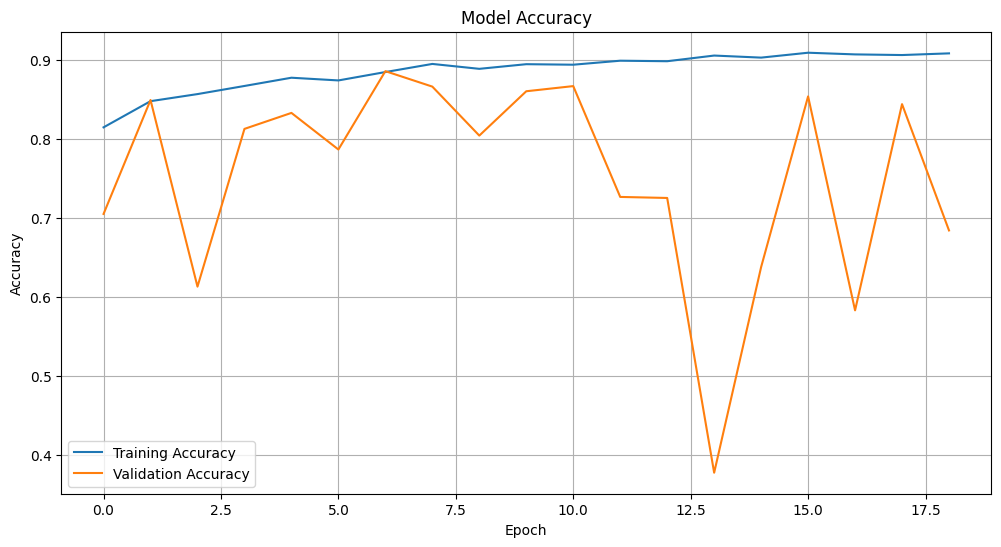

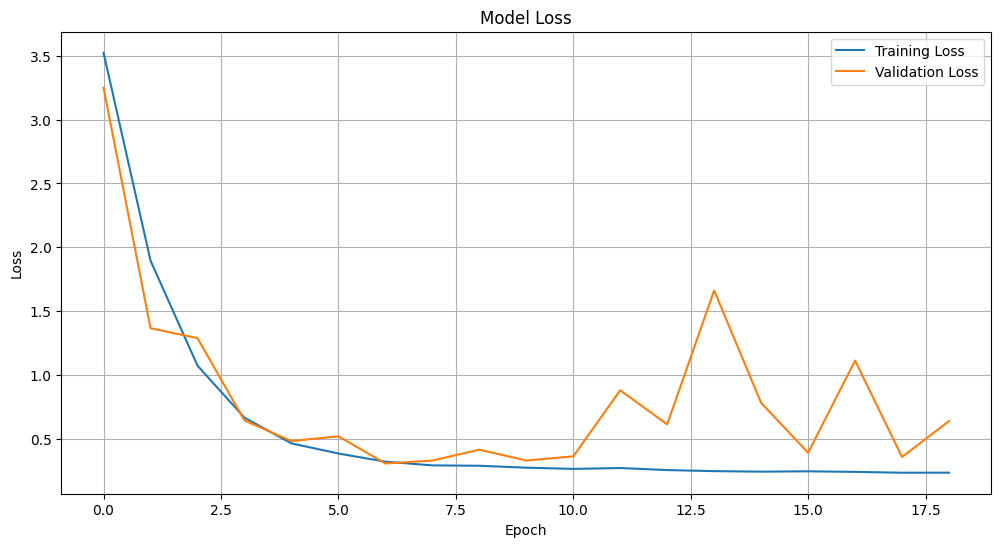

In [15]:
# Plot Loss and Accuracy During Training
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [16]:
# Evaluate the model on validation dataset
y_true = []
y_pred_probs = []

for batch in val_dataset.as_numpy_iterator():
    X, y = batch
    preds = model.predict(X)
    y_true.extend(y)
    y_pred_probs.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 984ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━

In [17]:
# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

In [18]:
# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred_probs)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

Accuracy: 0.8853
Precision: 0.9178
Recall: 0.9195
F1 Score: 0.9187
AUC-ROC: 0.9522


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


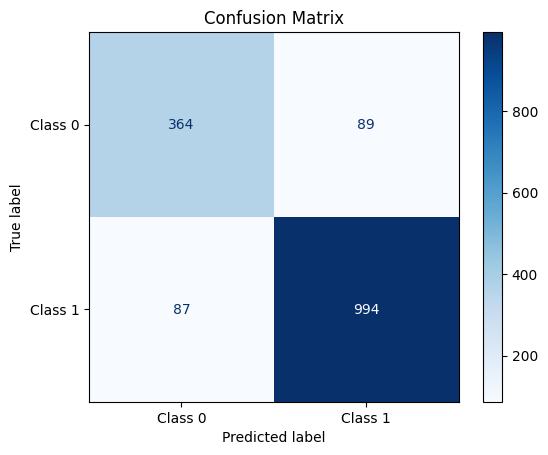

In [20]:
# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

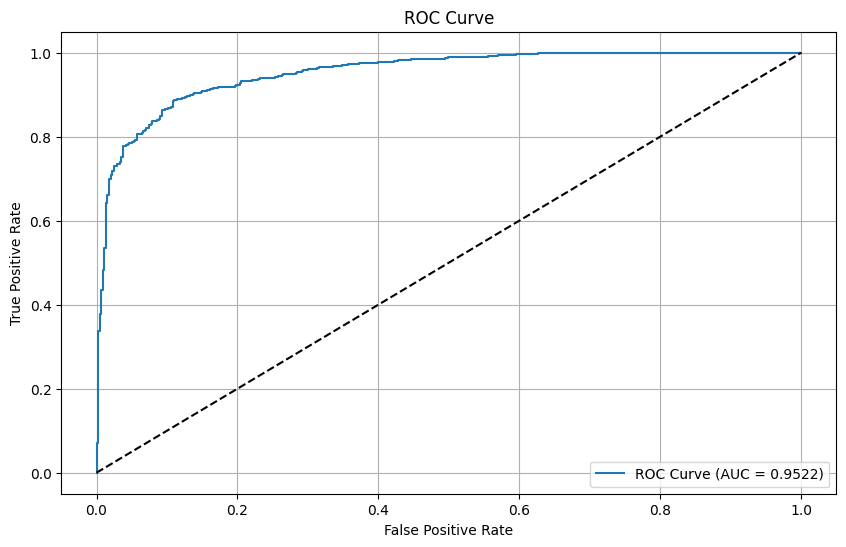

In [21]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()

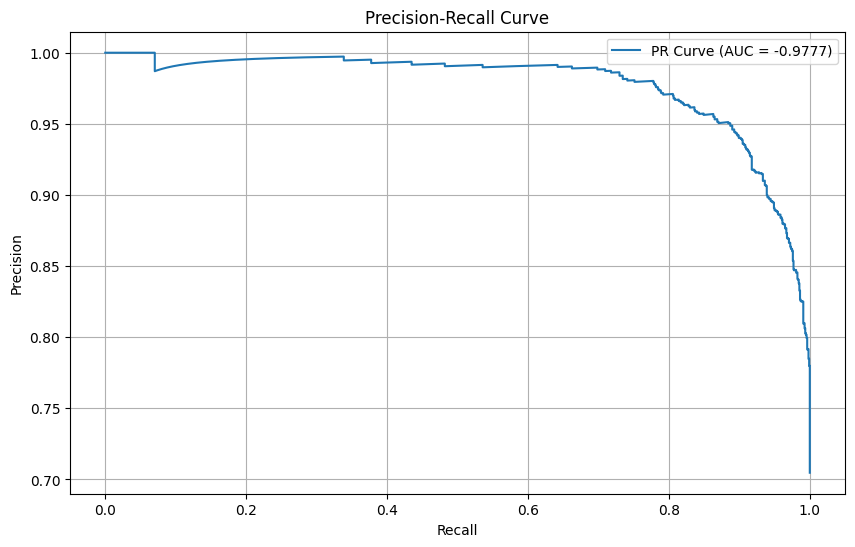

In [22]:
from sklearn.metrics import precision_recall_curve

# Plot PR Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_probs)
pr_auc = np.trapz(precision_vals, recall_vals)
plt.figure(figsize=(10, 6))
plt.plot(recall_vals, precision_vals, label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.grid()
plt.show()

In [23]:
import os

In [24]:
# Save the trained model
directory_path = '/content/drive/My Drive/saved_model'
model_path = os.path.join(directory_path, 'cnn_model_breast_danet_cbam.keras')
os.makedirs(directory_path, exist_ok=True)
model.save(model_path)
print(f"Model saved at: {model_path}")

Model saved at: /content/drive/My Drive/saved_model/cnn_model_breast_danet.keras


In [25]:
import os



In [27]:
from tensorflow.keras.models import load_model
import tensorflow as tf
import numpy as np

def test_single_class_dataset(dataset_dir, batch_size=1):
    model = load_model('/content/drive/My Drive/saved_model/cnn_model_breast_rand2.keras')

    # Prepare the dataset
    dataset = tf.keras.utils.image_dataset_from_directory(
        dataset_dir,
        image_size=(256, 256),
        batch_size=batch_size,
        label_mode='int'  # Labels are integers
    )

    # Normalize the data
    normalization_layer = tf.keras.layers.Rescaling(1./255)
    normalized_dataset = dataset.map(lambda x, y: (normalization_layer(x), y))

    # Evaluate the model
    total_samples = 0
    correct_predictions = 0

    for X, y in normalized_dataset:
        y_pred = model.predict(X)
        y_pred_binary = (y_pred > 0.4).astype(int).squeeze()  # Threshold at 0.4
        total_samples += len(y)
        correct_predictions += np.sum(y_pred_binary == y.numpy())  # Count correct predictions

    # Calculate accuracy
    accuracy = correct_predictions / total_samples
    print(f"Total Samples: {total_samples}")
    print(f"Correct Predictions: {correct_predictions}")
    print(f"Accuracy: {accuracy * 100:.2f}%")

if __name__ == "__main__":
    test_single_class_dataset('/content/drive/My Drive/mal')

TypeError: <class 'keras.src.models.sequential.Sequential'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras', 'class_name': 'Sequential', 'config': {'name': 'sequential_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None, 'shared_object_id': 138896335805680}, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': [None, 256, 256, 3], 'dtype': 'float32', 'sparse': False, 'name': 'input_layer_1'}, 'registered_name': None}, {'module': 'keras.layers', 'class_name': 'Conv2D', 'config': {'name': 'conv2d', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'filters': 32, 'kernel_size': [3, 3], 'strides

In [ ]:
from tensorflow.keras.models import load_model
import tensorflow as tf
import numpy as np

def test_single_class_dataset(dataset_dir, batch_size=1):
    model = load_model('/content/drive/My Drive/saved_model/cnn_model_breast_differenthypers.keras')

    # Prepare the dataset
    dataset = tf.keras.utils.image_dataset_from_directory(
        dataset_dir,
        image_size=(256, 256),
        batch_size=batch_size,
        label_mode='int'  # Labels are integers
    )

    # Normalize the data
    normalization_layer = tf.keras.layers.Rescaling(1./255)
    normalized_dataset = dataset.map(lambda x, y: (normalization_layer(x), y))

    # Evaluate the model
    total_samples = 0
    correct_predictions = 0

    for X, y in normalized_dataset:
        y_pred = model.predict(X)
        y_pred_binary = (y_pred < 0.4).astype(int).squeeze()  # Threshold at 0.4
        total_samples += len(y)
        correct_predictions += np.sum(y_pred_binary == y.numpy())  # Count correct predictions

    # Calculate accuracy
    accuracy = correct_predictions / total_samples
    print(f"Total Samples: {total_samples}")
    print(f"Correct Predictions: {correct_predictions}")
    print(f"Accuracy: {accuracy * 100:.2f}%")

if __name__ == "__main__":
    test_single_class_dataset('/content/drive/My Drive/beenn')